# My 12- and 8-inch designs

These are the two speakers that I use regularly. I have been working towards having the **sympy** version of my theory calculations become the basis for both my web app (in Javascript) and personal design explorations (in separate Jupyter notebooks). The idea is to finally have "one set of books" on theory and modeling without having to copy formulas by hand.

The theory notebook uses **jupyter nbconvert** to create a pure Python version of itself. This becomes the library that I use here.

In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from speakerTheorySympy import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 12-inch ported box using Eminence 2512-ii

In [3]:
eminence_2512ii_driver = {
    # Thiele-Small parameters from Eminence DeltaLite 2512-ii driver
    'Znom': 8.0, # Nominal impedance, Ohms
    #'P_e': 250, # Rated power, Watts, we don't use this.
    'f_s': 53.1, # Resonant frequency, Hz
    w_s: sp.N(53.1*2*sp.pi), # Resonant angular frequency, Hz
    R_e: 5.28, # DC resistance, Ohms
    L_e: 0.31*1e-3, # Voice coil inductance, H
    Q_ms: 2.94, # Mechanical Q factor
    Q_es: 0.64, # Electrical Q factor
    V_as: 67.44*1e-3, # Compliance equivalent air volume, m^3
    'X_max': 4.9*1e-3, # Maximum linear excursion, m
    S_d: 519.5*1e-4, # Diaphragm area, m^2
    # Additional physical constants
    rho: 1.2, # Air density, kg/m^3
    c: 343, # Speed of sound, m/s
    # System parameters
    'P_in_rms': 100, # Input power, Watts
    R_ref: 1.0, # Reference distance for SPL calculation, m
    P_ref: 20e-6, # Reference sound pressure for SPL calculation, Pa
}

finish_driver_params(eminence_2512ii_driver)

emi_box = {
    N_d: 1,
    V_box: 32*1e-3, # Box volume, liters converted to m^3
    f_port: 40,
    S_port: 21*3.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Znom': 8,
    'P_in_rms': 100}

emi_system = build_em_params(eminence_2512ii_driver, emi_box)
emi_system  = build_ported_params(emi_system, emi_box[f_port])

## 8 inch ported box using Faital Pro 8PR200 driver

In [4]:
faital_8pr200_driver = {
    # Thiele-Small parameters from Eminence DeltaLite 2512-ii driver
    'Znom': 8.0, # Nominal impedance, Ohms
    #'P_e': 250, # Rated power, Watts, we don't use this.
    'f_s': 58, # Resonant frequency, Hz
    w_s: sp.N(58*2*sp.pi), # Resonant angular frequency, Hz
    R_e: 5.1, # DC resistance, Ohms
    L_e: 0.55*1e-3, # Voice coil inductance, H
    Q_ms: 9.4, # Mechanical Q factor
    Q_es: 0.38, # Electrical Q factor
    V_as: 16.9*1e-3, # Compliance equivalent air volume, m^3
    'X_max': 8.15*1e-3, # Maximum linear excursion, m
    S_d: 209*1e-4, # Diaphragm area, m^2
    # Additional physical constants
    rho: 1.2, # Air density, kg/m^3
    c: 343, # Speed of sound, m/s
    # System parameters
    'P_in_rms': 100, # Input power, Watts
    R_ref: 1.0, # Reference distance for SPL calculation, m
    P_ref: 20e-6, # Reference sound pressure for SPL calculation, Pa
}

finish_driver_params(faital_8pr200_driver)

fai_box = {
    N_d: 1,
    V_box: 15*1e-3, # Box volume, liters converted to m^3
    f_port: 40,
    S_port: 5.5*5.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Z_nom': 8,
    'P_in_rms': 100}

fai_system = build_em_params(faital_8pr200_driver, fai_box)
fai_system  = build_ported_params(fai_system, fai_box[f_port])

## Possible redesign, more realistic box size, bigger port

In [13]:
fai_box_2 = fai_box = {
    N_d: 1,
    V_box: 12*1e-3, # Box volume, liters converted to m^3
    f_port: 40,
    S_port: 5.5*5.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Z_nom': 8,
    'P_in_rms': 100}

fai_system_2 = build_em_params(faital_8pr200_driver, fai_box_2)
fai_system_2  = build_ported_params(fai_system_2, fai_box_2[f_port])

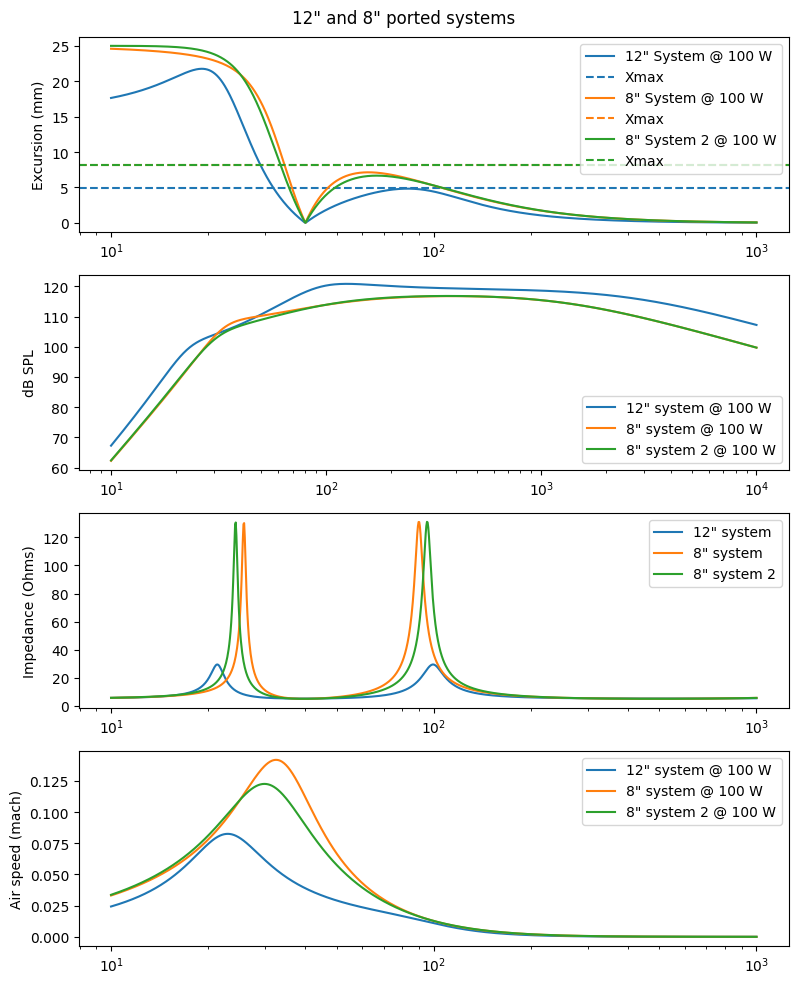

In [14]:
fig, axs = plt.subplots(4, figsize = (8, 10))
excursion_curve(emi_system, axs[0], label = '12" System @ 100 W')
excursion_curve(fai_system, axs[0], label = '8" System @ 100 W')
excursion_curve(fai_system_2, axs[0], label = '8" System 2 @ 100 W')

sensitivity_curve_ported(emi_system, axs[1], '12" system @ 100 W')
sensitivity_curve_ported(fai_system, axs[1], '8" system @ 100 W')
sensitivity_curve_ported(fai_system_2, axs[1], '8" system 2 @ 100 W')

impedance_curve(emi_system, axs[2], label = '12" system')
impedance_curve(fai_system, axs[2], label = '8" system')
impedance_curve(fai_system_2, axs[2], label = '8" system 2')

airspeed_curve_ported(emi_system, axs[3], '12" system @ 100 W')
airspeed_curve_ported(fai_system, axs[3], label = '8" system @ 100 W')
airspeed_curve_ported(fai_system_2, axs[3], label = '8" system 2 @ 100 W')

fig.suptitle('12" and 8" ported systems')
fig.tight_layout()

In [16]:
report_keys = ['Znom',
    'f_s',
    w_s,
    R_e,
    L_e,
    Q_ms,
    Q_es,
    V_as,
    'X_max',
    S_d,
    rho,
    c,
    'P_in_rms',
    R_ref,
    P_ref,
    V,
    'Q_ts',
    #C_ms,
    M_ms,
    R_ms,
    BL,
    C_ms_driver,
    V_box,
    f_port,
    S_port,
    L_port_m,
    'L_port_in']

for system in [emi_system, fai_system, fai_system_2]:
    system['L_port_in'] = system[L_port_m]/0.0254

df = pd.DataFrame([[tag, emi_system[tag], fai_system[tag], fai_system_2[tag]] for tag in report_keys])
df.columns = ['Parameter', '12" System', '8" System', '8" System 2']
df

,Parameter,"12"" System","8"" System","8"" System 2"
0,Znom,8,8.0,8.0
1,f_s,53.1,58,58
2,w_s,333.637139811236,364.424747816416,364.424747816416
3,R_e,5.28,5.1,5.1
4,L_e,0.00031,0.00055,0.00055
5,Q_ms,2.94,9.4,9.4
6,Q_es,0.64,0.38,0.38
7,V_as,0.06744,0.0169,0.0169
8,X_max,0.0049,0.00815,0.00815
9,S_d,0.05195,0.0209,0.0209


In [18]:
print('Did you remember to save first?')
!python3 -m jupyter nbconvert --to pdf ./12_and_8_inch_designs_sympy.ipynb

Did you remember to save first?
[NbConvertApp] Converting notebook ./12_and_8_inch_designs_sympy.ipynb to pdf
[NbConvertApp] Support files will be in 12_and_8_inch_designs_sympy_files/
[NbConvertApp] Making directory ./12_and_8_inch_designs_sympy_files
[NbConvertApp] Writing 42261 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 185920 bytes to 12_and_8_inch_designs_sympy.pdf
